In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
  # Change to the path where your CSV file is located
data = pd.read_csv('2023-Autonomous-Vehicle-Disengagement-Reports-CSV.csv', encoding='ISO-8859-1')

In [2]:
data.describe()

,Manufacturer,Permit Number,DATE,VIN NUMBER,VEHICLE IS CAPABLE OF OPERATING WITHOUT A DRIVER,DRIVER PRESENT,DISENGAGEMENT INITIATED BY,DISENGAGEMENT LOCATION,DESCRIPTION OF FACTS CAUSING DISENGAGEMENT
count,6562,6562,6562,6562,6562,6562,6562,6562,6562
unique,18,17,552,272,3,2,4,9,305
top,APPLE INC.,AVT030,11/20/23,4T1B21HK3KU514477,No,Yes,Test Driver,Freeway,The ADS incorrectly predicted the behavior of ...
freq,3194,3194,66,443,6522,6543,4767,2150,1926


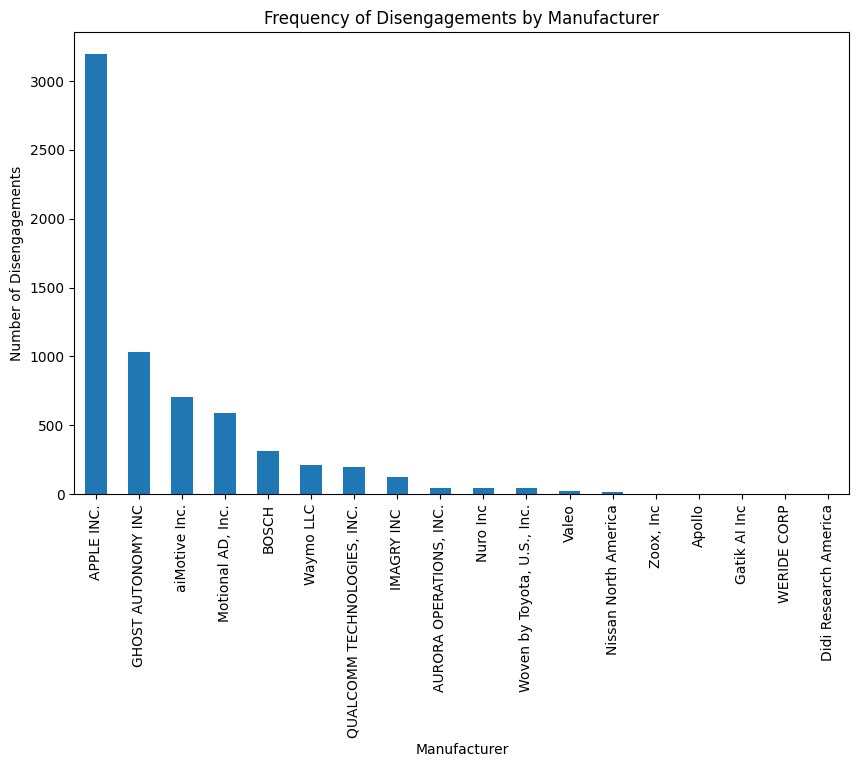

In [3]:
# Analysis 1: Frequency of Disengagements
disengagement_counts = data['Manufacturer'].value_counts()
plt.figure(figsize=(10, 6))
disengagement_counts.plot(kind='bar')
plt.title('Frequency of Disengagements by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Disengagements')
plt.show()

In [4]:
# Analysis 2: Disengagement Causes
# Count the unique descriptions
description_counts = data['DESCRIPTION OF FACTS CAUSING DISENGAGEMENT'].value_counts()

# Print the results
print(description_counts)

# Optionally, you can save this to a CSV file if the list is too long
description_counts.to_csv('disengagement_description_counts.csv')

DESCRIPTION OF FACTS CAUSING DISENGAGEMENT
The ADS incorrectly predicted the behavior of another road user, which resulted in a motion plan requiring disengagement by the Safety Driver.  The Safety Driver was able to safely take control of the vehicle.                      1926
The ADS initiated a disengagement due to a diagnosed hardware issue.  The Safety Driver was able to safely take control of the vehicle.                                                                                                 667
Precautionary Takeover: Disengaged due to a vehicle platform software issue within the Autonomous Vehicle's (AV) controller interface sub-system                                                                                        433
Safety Driver disengaged autonomous mode upon judging that vehicle was too close to road/lane boundary. Root cause: object, lane detection or other issue. Conditions: Non-inclement weather, dry roads, no other factors involved.     326
A discrepancy

In [17]:
def categorize_description(description):
    description = description.lower()  # Normalize text to lower case
    categories = {
        'Software Issues': ['software','planning logic', 'unexpected behavior', 'algorithm', 'glitch', 'traffic light', 'predicted', 'map', 'motion plan', 'compute infrastructure', 'software bug', 'software discrepancy', 'planning reference', 'planning behavior', 'path planning', 'cycle time', 'prediction'],
        'Hardware Issues': ['hardware', 'sensor input', 'component'],
        'Sensor and Perception Issues': ['sensor', 'incorrect perception', 'perception discrepency' 'lidar', 'localization', 'perceived', 'positioning', 'perception issue'],
        'External Conditions': ['light', 'obstacle', 'unexpected road conditions', 'sun glare', 'derbis', 'congestion', 'ODD'],
        'Distance Management': ['lane placement', 'lane marker', 'vehicle behavior', 'aggressive', 'lane change', 'maneuver', 're-center', 'steering', 'planning discrepency', 'distance', 'merge', 'too close', 'pedal', 'transitory', 'turning']
    }
    matched_categories = []
    for category, keywords in categories.items():
        if any(keyword in description for keyword in keywords):
            matched_categories.append(category)
    return matched_categories if matched_categories else ['Other']

# Apply the function
data['Categories'] = data['DESCRIPTION OF FACTS CAUSING DISENGAGEMENT'].apply(categorize_description)

data.to_csv('New.csv')

In [6]:
data.head()

,Manufacturer,Permit Number,DATE,VIN NUMBER,VEHICLE IS CAPABLE OF OPERATING WITHOUT A DRIVER,DRIVER PRESENT,DISENGAGEMENT INITIATED BY,DISENGAGEMENT LOCATION,DESCRIPTION OF FACTS CAUSING DISENGAGEMENT,Categories
0,aiMotive Inc.,AVT036,12/6/22,4T1B21HK6KU514747,No,Yes,"Test driver, AV system",Freeway,Safety Driver disengaged autonomous mode upon ...,[Distance Management]
1,aiMotive Inc.,AVT036,12/6/22,4T1B21HK3KU514477,No,Yes,"Test driver, AV system",Freeway,Safety Driver disengaged autonomous mode due d...,[External Conditions]
2,aiMotive Inc.,AVT036,12/8/22,4T1B21HK6KU514747,No,Yes,"Test driver, AV system",Freeway,Safety Driver disengaged autonomous mode due t...,[Sensor and Perception Issues]
3,aiMotive Inc.,AVT036,12/8/22,4T1B21HK6KU514747,No,Yes,"Test driver, AV system",Freeway,Safety Driver disengaged autonomous mode upon ...,[Distance Management]
4,aiMotive Inc.,AVT036,12/8/22,4T1B21HK3KU514477,No,Yes,"Test driver, AV system",Highway,Safety Driver disengaged autonomous mode as a ...,[Distance Management]


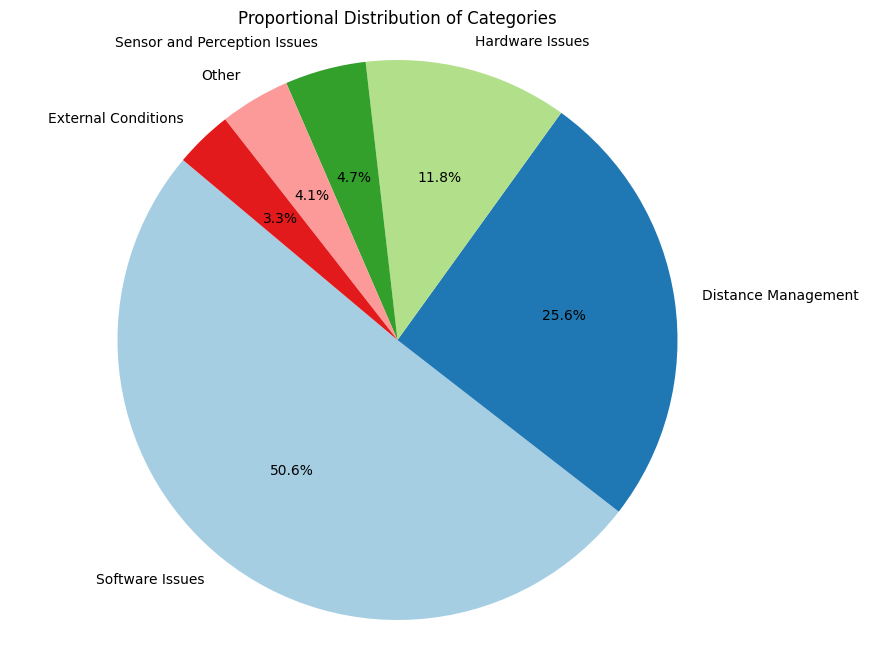

In [7]:
# Convert list of categories in each row into a Series of multiple rows
all_categories = data['Categories'].explode()

# Count the frequency of each category
category_counts = all_categories.value_counts()

# Plotting the results using a pie chart
plt.figure(figsize=(10, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(range(len(category_counts))))
plt.title('Proportional Distribution of Categories')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


  Location  Counts  Percentage
0  Freeway    3514   53.550747
1   Street    1580   24.078025
2  Highway    1348   20.542518
3    Other     120    1.828711


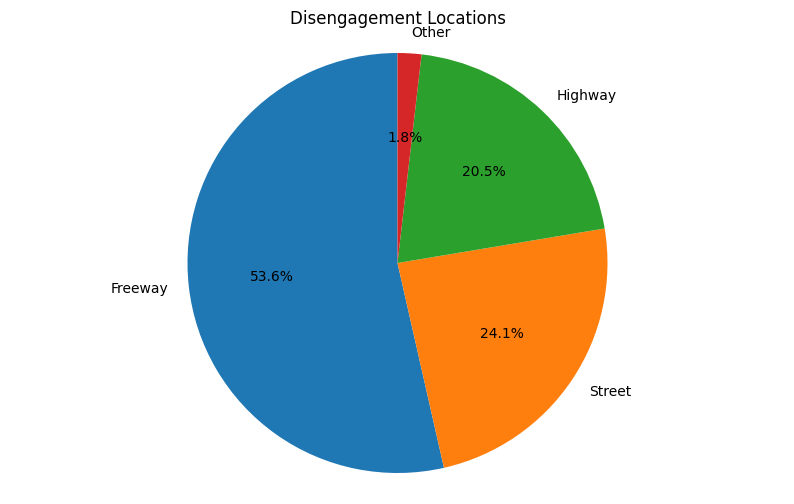

In [8]:
# Normalize location names to handle case and similar terms
location_mapping = {
    'freeway': 'Freeway',
    'interstate': 'Freeway',  # Merging Interstate with Freeway
    'highway': 'Highway',
    'express way': 'Other',  # Mapping Express Way to Other
    'parking facility': 'Other',  # Mapping Parking Facility to Other
    'urban': 'Other',
    'street': 'Street'  # Normalizing lowercase 'street'
}

# Normalize and map the location names
data['DISENGAGEMENT LOCATION'] = data['DISENGAGEMENT LOCATION'].str.lower().map(location_mapping)

# Recalculate location counts
location_counts = data['DISENGAGEMENT LOCATION'].value_counts()

# Calculate percentages
total_disengagements = location_counts.sum()
percentages = (location_counts / total_disengagements) * 100

# Create a DataFrame to display counts and percentages
locations_df = pd.DataFrame({
    'Location': location_counts.index,
    'Counts': location_counts.values,
    'Percentage': percentages.values
})

# Print the DataFrame
print(locations_df)

# Plotting the results using a pie chart
plt.figure(figsize=(10, 6))
plt.pie(location_counts, labels=location_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Disengagement Locations')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [9]:
data

,Manufacturer,Permit Number,DATE,VIN NUMBER,VEHICLE IS CAPABLE OF OPERATING WITHOUT A DRIVER,DRIVER PRESENT,DISENGAGEMENT INITIATED BY,DISENGAGEMENT LOCATION,DESCRIPTION OF FACTS CAUSING DISENGAGEMENT,Categories
0,aiMotive Inc.,AVT036,12/6/22,4T1B21HK6KU514747,No,Yes,"Test driver, AV system",Freeway,Safety Driver disengaged autonomous mode upon ...,[Distance Management]
1,aiMotive Inc.,AVT036,12/6/22,4T1B21HK3KU514477,No,Yes,"Test driver, AV system",Freeway,Safety Driver disengaged autonomous mode due d...,[External Conditions]
2,aiMotive Inc.,AVT036,12/8/22,4T1B21HK6KU514747,No,Yes,"Test driver, AV system",Freeway,Safety Driver disengaged autonomous mode due t...,[Sensor and Perception Issues]
3,aiMotive Inc.,AVT036,12/8/22,4T1B21HK6KU514747,No,Yes,"Test driver, AV system",Freeway,Safety Driver disengaged autonomous mode upon ...,[Distance Management]
4,aiMotive Inc.,AVT036,12/8/22,4T1B21HK3KU514477,No,Yes,"Test driver, AV system",Highway,Safety Driver disengaged autonomous mode as a ...,[Distance Management]
...,...,...,...,...,...,...,...,...,...,...
6557,"Woven by Toyota, U.S., Inc.",AVT077,10/30/23 19:07,JTHCYLFF0J5001364,No,Yes,Test Driver,Street,Safety Driver disengaged to re-center vehicle ...,[Distance Management]
6558,"Zoox, Inc",AVT012,2/15/23,~8312,No,Yes,Test Driver,Street,Prediction discrepancy. Late and illegal cut-i...,[Software Issues]
6559,"Zoox, Inc",AVT012,3/17/23,~9086,No,Yes,Test Driver,Street,Prediction discrepancy. Adjacent vehicle made ...,"[Software Issues, Distance Management]"
6560,"Zoox, Inc",AVT012,3/23/23,~8948,No,Yes,Test Driver,Street,Prediction discrepancy. Adjacent vehicle made ...,"[Software Issues, Distance Management]"


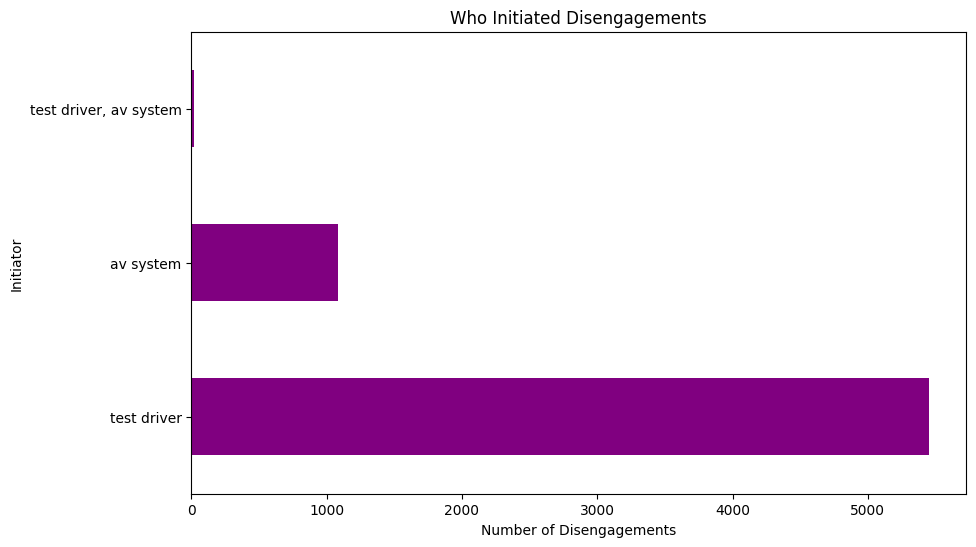

In [10]:

# Assuming 'data' is your DataFrame and the column 'DISENGAGEMENT INITIATED BY' contains the initiator data
# Normalize the initiator names to lowercase to avoid case-sensitive discrepancies
data['DISENGAGEMENT INITIATED BY'] = data['DISENGAGEMENT INITIATED BY'].str.lower()

# Recalculate the counts
initiation_counts = data['DISENGAGEMENT INITIATED BY'].value_counts()

# Plotting the results using a horizontal bar chart
plt.figure(figsize=(10, 6))
initiation_counts.plot(kind='barh', color='purple')  # Using horizontal bar chart for better readability
plt.title('Who Initiated Disengagements')
plt.xlabel('Number of Disengagements')
plt.ylabel('Initiator')
plt.show()


In [11]:
initiation_counts

DISENGAGEMENT INITIATED BY
test driver               5454
av system                 1087
test driver, av system      21
Name: count, dtype: int64

In [12]:
import pandas as pd

# Load the data
df = pd.read_csv('Disengagement reports CategoriesMod.csv')

# Assuming categories are stored as string representations of lists
# Convert them to actual lists
import ast
df['Categories'] = df['Categories'].apply(ast.literal_eval)

# Use MultiLabelBinarizer from sklearn to convert categories to one-hot encoding
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()

# Transform the categories and create a new DataFrame from the results
df_encoded = pd.DataFrame(mlb.fit_transform(df['Categories']), columns=mlb.classes_, index=df.index)

# Concatenate the original DataFrame with the new one
result = pd.concat([df, df_encoded], axis=1)

# Optionally, drop the original Categories column if you no longer need it
result.drop('Categories', axis=1, inplace=True)

# Save the result to a new CSV file
result.to_csv('dataML encoded.csv', index=False)


In [13]:
# Drop the redundant index column
result.drop(columns=['Unnamed: 0'], inplace=True)
# Convert 'DATE' to datetime
result['DATE'] = pd.to_datetime(result['DATE'])

# Converting binary categorical columns to numeric using mapping
binary_columns = ['VEHICLE IS CAPABLE OF OPERATING WITHOUT A DRIVER', 'DRIVER PRESENT']
binary_mapping = {'Yes': 1, 'No': 0}
data[binary_columns] = result[binary_columns].applymap(binary_mapping.get)

# One-hot encode other categorical columns
categorical_columns = ['Manufacturer', 'DISENGAGEMENT INITIATED BY', 'DISENGAGEMENT LOCATION']
result = pd.get_dummies(result, columns=categorical_columns)


# Convert boolean columns to integers
for col in result.columns:
    if result[col].dtype == 'bool':
        result[col] = result[col].astype(int)

# Display updated DataFrame and data types
result.head(), result.dtypes

result.to_csv('dataML encoded3.csv', index=False)



/var/folders/76/53hj2t212512j_3_p2ptnwcw0000gn/T/ipykernel_53640/1967294649.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  result['DATE'] = pd.to_datetime(result['DATE'])
/var/folders/76/53hj2t212512j_3_p2ptnwcw0000gn/T/ipykernel_53640/1967294649.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[binary_columns] = result[binary_columns].applymap(binary_mapping.get)


/var/folders/76/53hj2t212512j_3_p2ptnwcw0000gn/T/ipykernel_53640/2471688010.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mileage['Annual Total of Disengagements'].replace(0, pd.NA, inplace=True)  # Replace 0 with NA to avoid division by zero


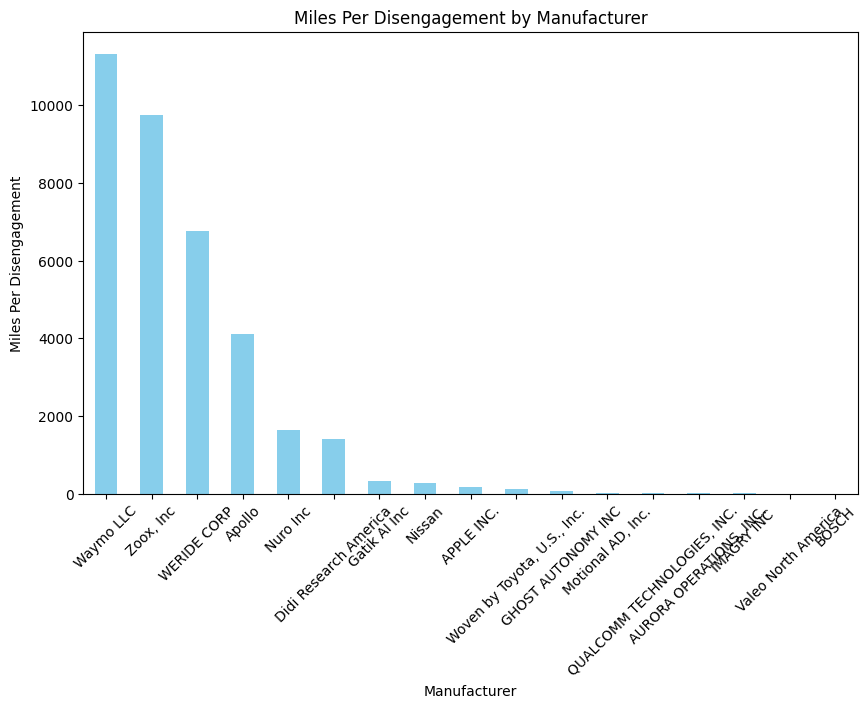

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file, specify usecols to exclude unwanted 'Unnamed' columns if they are always at the end and consistent
mileage = pd.read_csv('2023-Autonomous-Mileage-Reports-CSV.csv', usecols=lambda column: not column.startswith('Unnamed'))

# Check data types and convert 'ANNUAL TOTAL' to numeric, coercing errors to NaN
mileage['ANNUAL TOTAL'] = pd.to_numeric(mileage['ANNUAL TOTAL'], errors='coerce')

# Drop rows where 'ANNUAL TOTAL' is NaN if these rows cannot be recovered
mileage.dropna(subset=['ANNUAL TOTAL'], inplace=True)

# Ensure the 'Annual Total of Disengagements' is numeric and handle zero disengagements to avoid infinite values
mileage['Annual Total of Disengagements'] = pd.to_numeric(mileage['Annual Total of Disengagements'], errors='coerce')
mileage['Annual Total of Disengagements'].replace(0, pd.NA, inplace=True)  # Replace 0 with NA to avoid division by zero

# Calculate miles per disengagement safely
mileage['Miles Per Disengagement'] = mileage['ANNUAL TOTAL'].div(mileage['Annual Total of Disengagements'])

# Drop rows with infinite or NaN values in 'Miles Per Disengagement'
mileage.dropna(subset=['Miles Per Disengagement'], inplace=True)

# Group the data by 'Manufacturer'
manufacturer_group = mileage.groupby('Manufacturer')

# Get counts of entries for each manufacturer
manufacturer_counts = manufacturer_group.size()

# Group the data by 'Manufacturer' and calculate the mean
manufacturer_group = mileage.groupby('Manufacturer')['Miles Per Disengagement'].mean().sort_values(ascending=False)

# Plotting the results using a bar chart
plt.figure(figsize=(10, 6))
manufacturer_group.plot(kind='bar', color='skyblue')
plt.title('Miles Per Disengagement by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Miles Per Disengagement')
plt.xticks(rotation=45)  # Rotate manufacturer names for better visibility
plt.show()


In [15]:
manufacturer_group.to_csv('Miles Per Disengagement.csv')

In [16]:
manufacturer_group

Manufacturer
Waymo LLC                      11330.395869
Zoox, Inc                           9751.85
WERIDE CORP                         6755.94
Apollo                          4123.233333
Nuro Inc                         1637.14164
Didi Research America                1408.7
Gatik AI Inc                          317.0
Nissan                              277.125
APPLE INC.                       174.095653
Woven by Toyota, U.S., Inc.      112.556548
GHOST AUTONOMY INC                69.109522
Motional AD, Inc.                 30.370105
QUALCOMM TECHNOLOGIES, INC.       19.885225
AURORA OPERATIONS, INC.           14.899149
IMAGRY INC                         5.845863
Valeo North America                4.952381
BOSCH                              3.212809
Name: Miles Per Disengagement, dtype: object